► Промоделировать 1000 событий с энергий 1 МэВ в центре детектора. Построить распределение полного собранного заряда.

► Повторить процедуру для энергий 0.2, 0.5, 0.7, 1.5, 2.0, 3.0 МэВ. Как относительная ширина распределения зависит от энергии?

► Повторить процедуру для источника, смещенного на 1 метр по оси z. Насколько меняется среднее значение для собранного заряда?

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy import pi, sin, cos, arccos, sqrt, random, column_stack, linalg

In [2]:
%run task_1_Detector.ipynb
%run task_2_Source.ipynb
%run task_3_model.ipynb

Точка в центре ФЭУ №0 принадлежит ФЭУ? True
Энергия события: 5.0 МэВ
Ожидаемое число фотонов: 50000
Фактически сгенерировано фотонов: 50296
Точка в центре ФЭУ №0 принадлежит ФЭУ? True
Энергия события: 5.0 МэВ
Ожидаемое число фотонов: 50000
Фактически сгенерировано фотонов: 49748
Всего сгенерировано фотонов (среднее 10000.0): 10051
Полный собранный заряд (фотоэлектронов): 123
Ожидаемый Q (по формуле из условия): 500.00


In [3]:
def simulate_events(E, num_events, start_pos, detector, source):
    charges = np.zeros(num_events)
    for i in range(num_events):
        directions = source.generate_photons(E)
        q_event = 0
        for direction in directions:
            if track_photon_to_boundary(start_pos, direction, detector):
                q_event += random.poisson(detector.a)
        charges[i] = q_event
        
        if (i + 1) % 200 == 0:
            print(f"  Обработано событий: {i + 1}/{num_events}")
            
    return charges

In [4]:
detector = Detector(R=2.0, N=40, r_cm=10.0, a=0.5)
source = Source(Y=10000)

In [5]:
charges_1MeV_center = simulate_events(1.0, 1000, [0.0, 0.0, 0.0], detector, source)

  Обработано событий: 200/1000
  Обработано событий: 400/1000
  Обработано событий: 600/1000
  Обработано событий: 800/1000
  Обработано событий: 1000/1000


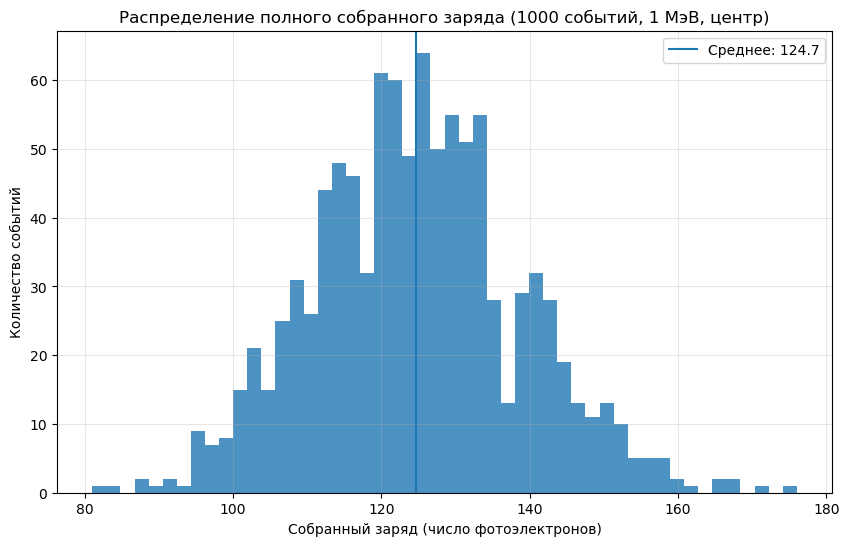

In [6]:
plt.figure(figsize=(10, 6))
plt.hist(charges_1MeV_center, bins=50, alpha=0.8)
mean_1 = np.mean(charges_1MeV_center)
std_1 = np.std(charges_1MeV_center)
plt.axvline(mean_1, label=f'Среднее: {mean_1:.1f}')
plt.title('Распределение полного собранного заряда (1000 событий, 1 МэВ, центр)')
plt.xlabel('Собранный заряд (число фотоэлектронов)')
plt.ylabel('Количество событий')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [7]:
energies = [0.2, 0.5, 0.7, 1.0, 1.5, 2.0, 3.0]
results = []

In [8]:
for E in energies:
    
    print(f"  Моделирование E = {E} МэВ...")
    
    if E == 1.0:
        charges = charges_1MeV_center
    else:
        charges = simulate_events(E, 500, [0.0, 0.0, 0.0], detector, source)
    
    mean_q = np.mean(charges)
    std_q = np.std(charges)
    rel_width = std_q / mean_q
    results.append({'E': E, 'Mean': mean_q, 'Std': std_q, 'RelWidth': rel_width})

  Моделирование E = 0.2 МэВ...
  Обработано событий: 200/500
  Обработано событий: 400/500
  Моделирование E = 0.5 МэВ...
  Обработано событий: 200/500
  Обработано событий: 400/500
  Моделирование E = 0.7 МэВ...
  Обработано событий: 200/500
  Обработано событий: 400/500
  Моделирование E = 1.0 МэВ...
  Моделирование E = 1.5 МэВ...
  Обработано событий: 200/500
  Обработано событий: 400/500
  Моделирование E = 2.0 МэВ...
  Обработано событий: 200/500
  Обработано событий: 400/500
  Моделирование E = 3.0 МэВ...
  Обработано событий: 200/500
  Обработано событий: 400/500


In [9]:
print(f"{'Энергия (МэВ)':<15} | {'Средний Q':<10} | {'Стд. откл. (σ)':<15} | {'Отн. ширина (σ/μ)':<15}")
print("-" * 70)
for res in results:
    print(f"{res['E']:<15.1f} | {res['Mean']:<10.1f} | {res['Std']:<15.1f} | {res['RelWidth']:<15.4f}")

Энергия (МэВ)   | Средний Q  | Стд. откл. (σ)  | Отн. ширина (σ/μ)
----------------------------------------------------------------------
0.2             | 25.1       | 6.3             | 0.2511         
0.5             | 62.5       | 9.3             | 0.1482         
0.7             | 87.5       | 11.5            | 0.1313         
1.0             | 124.7      | 14.0            | 0.1122         
1.5             | 188.2      | 16.7            | 0.0889         
2.0             | 250.3      | 19.6            | 0.0782         
3.0             | 375.8      | 23.1            | 0.0614         


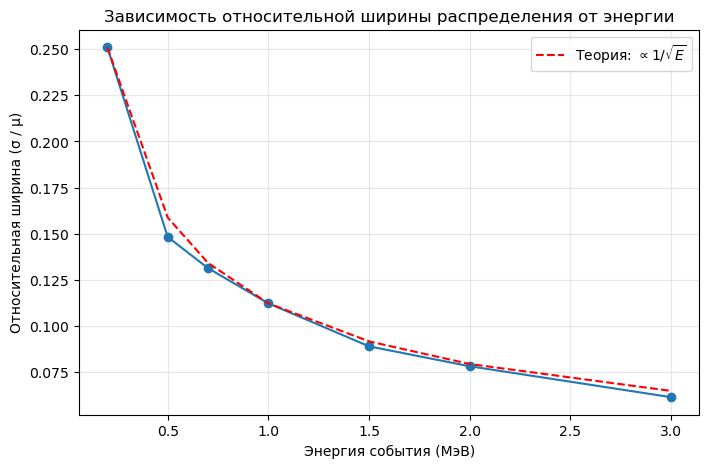

In [10]:
plt.figure(figsize=(8, 5))
e_vals = [r['E'] for r in results]
rw_vals = [r['RelWidth'] for r in results]
plt.plot(e_vals, rw_vals, 'o-')

theoretical_rw = [rw_vals[3] * sqrt(1.0 / e) for e in e_vals]
plt.plot(e_vals, theoretical_rw, '--', color='red', label=r'Теория: $\propto 1/\sqrt{E}$')

plt.title('Зависимость относительной ширины распределения от энергии')
plt.xlabel('Энергия события (МэВ)')
plt.ylabel('Относительная ширина (σ / μ)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [11]:
charges_1MeV_shifted = simulate_events(1.0, 1000, [0.0, 0.0, 1.0], detector, source)

  Обработано событий: 200/1000
  Обработано событий: 400/1000
  Обработано событий: 600/1000
  Обработано событий: 800/1000
  Обработано событий: 1000/1000


In [12]:
mean_shifted = np.mean(charges_1MeV_shifted)
mean_center = np.mean(charges_1MeV_center)
diff_percent = ((mean_shifted - mean_center) / mean_center) * 100

In [13]:
print(f"Средний заряд в центре (z=0):       {mean_center:.1f} фэ")
print(f"Средний заряд при смещении (z=1.0): {mean_shifted:.1f} фэ")
print(f"Относительное изменение:            {diff_percent:+.2f}%")

Средний заряд в центре (z=0):       124.7 фэ
Средний заряд при смещении (z=1.0): 124.9 фэ
Относительное изменение:            +0.18%
